## XGBM & LGBM Assignment

In [2]:
# Step 1: Import Required Libraries
# Import necessary libraries for data handling, visualization, and model building.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import xgboost as xgb
import lightgbm as lgb

In [4]:
# Step 2: Load and Explore the Dataset
# Load the Titanic dataset
train_data_path = 'Titanic_train.csv'
test_data_path = 'Titanic_test.csv'

df_train = pd.read_csv(train_data_path)
df_test = pd.read_csv(test_data_path)

# Display the first few rows of the training dataset
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
# Step 3: Exploratory Data Analysis (EDA)
# Check for missing values
print("\nMissing Values in Train Dataset:")
print(df_train.isnull().sum())


Missing Values in Train Dataset:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


/var/folders/26/00slbxsd34bg6pgc2vpx2k700000gn/T/ipykernel_44060/180792574.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df_train, palette='coolwarm')


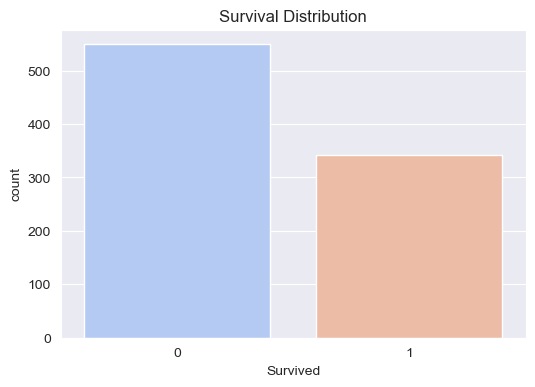

In [6]:
# Visualize survival distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', data=df_train, palette='coolwarm')
plt.title("Survival Distribution")
plt.show()

/var/folders/26/00slbxsd34bg6pgc2vpx2k700000gn/T/ipykernel_44060/2004844303.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=df_train, palette='coolwarm')


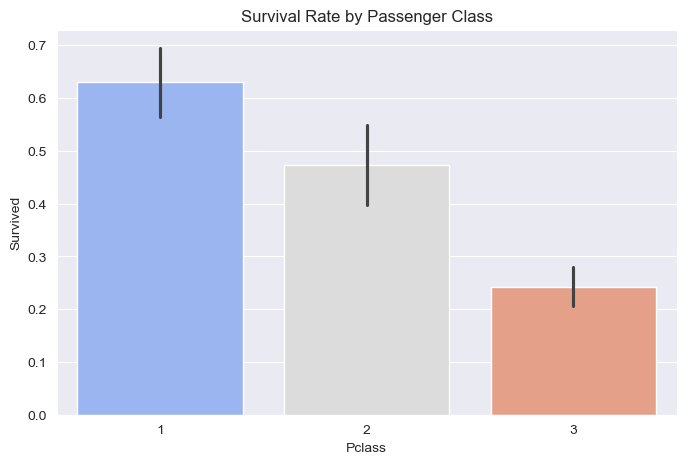

In [7]:
# Explore relationships between features and survival
plt.figure(figsize=(8, 5))
sns.barplot(x='Pclass', y='Survived', data=df_train, palette='coolwarm')
plt.title("Survival Rate by Passenger Class")
plt.show()

In [9]:
#Step 4: Data Preprocessing
# Impute missing values
for df in [df_train, df_test]:
    df['Age'].fillna(df['Age'].median(), inplace=True)
    df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
    df['Fare'].fillna(df['Fare'].median(), inplace=True)

/var/folders/26/00slbxsd34bg6pgc2vpx2k700000gn/T/ipykernel_44060/3726255397.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/var/folders/26/00slbxsd34bg6pgc2vpx2k700000gn/T/ipykernel_44060/3726255397.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values al

In [10]:
# Encode categorical variables using Label Encoding
label_encoders = {}
for col in ['Sex', 'Embarked']:
    le = LabelEncoder()
    df_train[col] = le.fit_transform(df_train[col])
    df_test[col] = le.transform(df_test[col])
    label_encoders[col] = le

In [11]:
# Select relevant features for training
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
X = df_train[features]
y = df_train['Survived']

In [12]:
# Standardize the features
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_test = scaler.transform(df_test[features])

In [13]:
# Split the dataset into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [14]:
# Step 5: Build Predictive Models
# Initialize and train XGBoost model
xgb_model = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42)
xgb_model.fit(X_train, y_train)


/opt/anaconda3/envs/assignments/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [23:37:03] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [15]:
# Make predictions on the validation set
y_pred_xgb = xgb_model.predict(X_val)


In [16]:
# Initialize and train LightGBM model
lgb_model = lgb.LGBMClassifier(objective='binary', random_state=42)
lgb_model.fit(X_train, y_train)


[LightGBM] [Info] Number of positive: 273, number of negative: 439
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000055 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383427 -> initscore=-0.475028
[LightGBM] [Info] Start training from score -0.475028
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


LGBMClassifier(objective='binary', random_state=42)

In [17]:
# Make predictions on the validation set
y_pred_lgb = lgb_model.predict(X_val)


In [18]:
# Step 6: Evaluate Model Performance
# Define function to compute performance metrics
def evaluate_model(y_true, y_pred, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    print(f"\nPerformance Metrics for {model_name}:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))


In [19]:
# Evaluate both models
evaluate_model(y_val, y_pred_xgb, "XGBoost")
evaluate_model(y_val, y_pred_lgb, "LightGBM")



Performance Metrics for XGBoost:
Accuracy: 0.8156
Precision: 0.7647
Recall: 0.7536
F1 Score: 0.7591
Confusion Matrix:
[[94 16]
 [17 52]]

Performance Metrics for LightGBM:
Accuracy: 0.7989
Precision: 0.7538
Recall: 0.7101
F1 Score: 0.7313
Confusion Matrix:
[[94 16]
 [20 49]]


In [20]:
# Step 7: Hyperparameter Tuning using GridSearchCV
# Define parameter grid for XGBoost
xgb_params = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [50, 100, 200]
}

In [21]:
grid_xgb = GridSearchCV(xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False),
                        param_grid=xgb_params, scoring='accuracy', cv=3, verbose=2)
grid_xgb.fit(X_train, y_train)
print("\nBest Parameters for XGBoost:", grid_xgb.best_params_)

# Define parameter grid for LightGBM
lgb_params = {
    'num_leaves': [31, 50, 100],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [50, 100, 200]
}

Fitting 3 folds for each of 27 candidates, totalling 81 fits
[CV] END ...learning_rate=0.01, max_depth=3, n_estimators=50; total time=   0.0s
[CV] END ...learning_rate=0.01, max_depth=3, n_estimators=50; total time=   0.0s
[CV] END ...learning_rate=0.01, max_depth=3, n_estimators=50; total time=   0.0s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=100; total time=   0.0s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=100; total time=   0.0s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=100; total time=   0.0s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=200; total time=   0.0s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=200; total time=   0.0s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=200; total time=   0.0s
[CV] END ...learning_rate=0.01, max_depth=5, n_estimators=50; total time=   0.0s
[CV] END ...learning_rate=0.01, max_depth=5, n_estimators=50; total time=   0.0s
[CV] END ...learning_rate=0.01, max_depth=5, n_e

/opt/anaconda3/envs/assignments/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [23:37:48] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/envs/assignments/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [23:37:48] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/envs/assignments/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [23:37:48] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/envs/assig

[CV] END ..learning_rate=0.01, max_depth=5, n_estimators=100; total time=   0.0s
[CV] END ..learning_rate=0.01, max_depth=5, n_estimators=100; total time=   0.0s
[CV] END ..learning_rate=0.01, max_depth=5, n_estimators=100; total time=   0.0s
[CV] END ..learning_rate=0.01, max_depth=5, n_estimators=200; total time=   0.1s
[CV] END ..learning_rate=0.01, max_depth=5, n_estimators=200; total time=   0.0s


/opt/anaconda3/envs/assignments/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [23:37:49] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/envs/assignments/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [23:37:49] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/envs/assignments/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [23:37:49] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/envs/assig

[CV] END ..learning_rate=0.01, max_depth=5, n_estimators=200; total time=   0.1s
[CV] END ...learning_rate=0.01, max_depth=7, n_estimators=50; total time=   0.0s
[CV] END ...learning_rate=0.01, max_depth=7, n_estimators=50; total time=   0.0s
[CV] END ...learning_rate=0.01, max_depth=7, n_estimators=50; total time=   0.0s
[CV] END ..learning_rate=0.01, max_depth=7, n_estimators=100; total time=   0.0s
[CV] END ..learning_rate=0.01, max_depth=7, n_estimators=100; total time=   0.0s
[CV] END ..learning_rate=0.01, max_depth=7, n_estimators=100; total time=   0.0s
[CV] END ..learning_rate=0.01, max_depth=7, n_estimators=200; total time=   0.1s


...

/opt/anaconda3/envs/assignments/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [23:37:51] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/envs/assignments/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [23:37:51] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/envs/assignments/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [23:37:51] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/envs/assig

[CV] END ....learning_rate=0.2, max_depth=7, n_estimators=50; total time=   0.0s
[CV] END ...learning_rate=0.2, max_depth=7, n_estimators=100; total time=   0.0s
[CV] END ...learning_rate=0.2, max_depth=7, n_estimators=100; total time=   0.0s
[CV] END ...learning_rate=0.2, max_depth=7, n_estimators=100; total time=   0.0s
[CV] END ...learning_rate=0.2, max_depth=7, n_estimators=200; total time=   0.0s
[CV] END ...learning_rate=0.2, max_depth=7, n_estimators=200; total time=   0.0s


/opt/anaconda3/envs/assignments/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [23:37:51] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/envs/assignments/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [23:37:51] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/envs/assignments/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [23:37:51] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/envs/assig

[CV] END ...learning_rate=0.2, max_depth=7, n_estimators=200; total time=   0.1s

Best Parameters for XGBoost: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}


/opt/anaconda3/envs/assignments/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [23:37:51] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [22]:
grid_lgb = GridSearchCV(lgb.LGBMClassifier(objective='binary'),
                        param_grid=lgb_params, scoring='accuracy', cv=3, verbose=2)
grid_lgb.fit(X_train, y_train)
print("\nBest Parameters for LightGBM:", grid_lgb.best_params_)


Fitting 3 folds for each of 27 candidates, totalling 81 fits
[LightGBM] [Info] Number of positive: 182, number of negative: 292
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000141 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 172
[LightGBM] [Info] Number of data points in the train set: 474, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383966 -> initscore=-0.472747
[LightGBM] [Info] Start training from score -0.472747
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Li

In [23]:
# Step 8: Comparative Analysis and Conclusion
# Retrain models with best parameters
best_xgb = grid_xgb.best_estimator_
best_lgb = grid_lgb.best_estimator_

# Predict and evaluate
y_pred_best_xgb = best_xgb.predict(X_val)
y_pred_best_lgb = best_lgb.predict(X_val)

evaluate_model(y_val, y_pred_best_xgb, "Optimized XGBoost")
evaluate_model(y_val, y_pred_best_lgb, "Optimized LightGBM")

# Compare results
if accuracy_score(y_val, y_pred_best_xgb) > accuracy_score(y_val, y_pred_best_lgb):
    print("XGBoost outperformed LightGBM in terms of accuracy.")
else:
    print("LightGBM outperformed XGBoost in terms of accuracy.")



Performance Metrics for Optimized XGBoost:
Accuracy: 0.8045
Precision: 0.7931
Recall: 0.6667
F1 Score: 0.7244
Confusion Matrix:
[[98 12]
 [23 46]]

Performance Metrics for Optimized LightGBM:
Accuracy: 0.7933
Precision: 0.7667
Recall: 0.6667
F1 Score: 0.7132
Confusion Matrix:
[[96 14]
 [23 46]]
XGBoost outperformed LightGBM in terms of accuracy.


In [24]:
# Step 9: Practical Implications
# - XGBoost is useful for structured datasets with missing values and categorical data.
# - LightGBM is efficient for large datasets due to its leaf-wise growth strategy.
# - Feature importance analysis can help in further model optimization.
# - Hyperparameter tuning significantly improves performance.
